In [1]:
# from numba import njit, prange
import numpy as np
import faiss

index_ = [0, 0, 0, 0]
# index_ = [325, 80, 47, 149]

data = np.load(
    f"../data/save/train_test-{index_[0]}-{index_[1]}-{index_[2]}-{index_[3]}.npz"
)

x = np.array(data["x"], dtype=np.float32)
y = np.array(data["y"], dtype=np.float32)
w = np.array(data["w"], dtype=np.float32)
coor = np.array(data["coor"], dtype=np.int64)

In [2]:
(num_sample, dim_sample) = x.shape
res = faiss.StandardGpuResources()
flat_config = faiss.GpuIndexFlatConfig()
flat_config.device = 0
index = faiss.GpuIndexFlatL2(res, dim_sample, flat_config)
index.add(x)

In [3]:
b = x.copy()
min_number = 100
distances, indices = index.search(b, min_number)
name = data["name"]

var_y = np.var(np.einsum("ij,i->ij", y[indices], x[:, 0] * w), axis=1)

mean_of_distances = np.max(distances, axis=1)
mean_of_distances[mean_of_distances < 0.001] = -1
mean_of_distances[mean_of_distances > 0.001] = 0
mean_of_distances = -mean_of_distances

argsort_ = np.argsort(mean_of_distances * var_y)[::-1][:100]

energy = np.einsum("ij,i->ij", y[indices[argsort_]], (x[:, 0] * w)[argsort_])
distances = distances[argsort_]
name = name[indices[argsort_]]

In [7]:
# (sum_of_distances_reverse * var_y)[argsort_]
index_check = 11
print(
    np.sum(
        (x[indices[argsort_[index_check]]] - x[indices[argsort_[index_check]]][0]) ** 2,
        axis=1,
    )
)
print(np.max(distances[index_check]))
print(np.max(np.abs((energy[index_check] - energy[index_check][0]) * 627.509)))
print(name[index_check])

[0.0000000e+00 2.7676664e-05 4.7921705e-05 1.0476954e-04 1.6441592e-04
 2.2515676e-04 3.0721928e-04 3.2869045e-04 3.3109472e-04 3.7762057e-04
 3.8521300e-04 3.8677387e-04 3.9358248e-04 4.2552839e-04 4.3506449e-04
 4.3831754e-04 4.3981831e-04 4.4542493e-04 4.5558321e-04 4.5946529e-04
 4.6859306e-04 4.7718201e-04 4.7812299e-04 4.9871573e-04 5.0059694e-04
 5.0245674e-04 5.0302316e-04 5.0878985e-04 5.1309564e-04 5.1339099e-04
 5.1727198e-04 5.1986356e-04 5.2331953e-04 5.3038675e-04 5.3714885e-04
 5.4033584e-04 5.4063689e-04 5.4265995e-04 5.5593019e-04 5.6552386e-04
 5.6560658e-04 5.6572625e-04 5.7829998e-04 5.8266392e-04 5.9691013e-04
 5.9939729e-04 6.0618710e-04 6.1283424e-04 6.3738809e-04 6.4849493e-04
 6.5475726e-04 6.6286774e-04 6.7053229e-04 6.7252934e-04 6.7947822e-04
 6.8195892e-04 6.9882598e-04 7.1379554e-04 7.1530958e-04 7.2591048e-04
 7.3049392e-04 7.3229830e-04 7.3737808e-04 7.4768014e-04 7.5428019e-04
 7.5456133e-04 7.5599982e-04 7.5678289e-04 7.5988169e-04 7.6102064e-04
 7.661

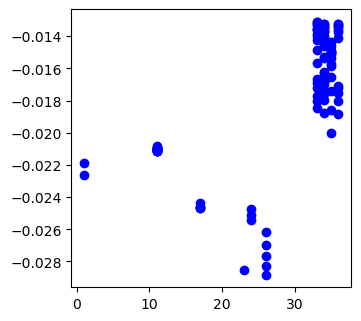

In [8]:
from matplotlib import pyplot as plt

plt.rcParams["figure.figsize"] = np.array([0.5, 0.5]) * 520 / 72
name_energy_dict = {}

for i in range(min_number):
    name_energy_dict[name[index_check][i]] = energy[index_check][i] * 627.509


name_dict = {
    "methane": 0,
    "ethane": 1,
    "ethylene": 2,
    "acetylene": 3,
}

x_name_dict = {}
x_energy_dict = {}

for name_i, energy_i in name_energy_dict.items():
    x_ = name_dict[name_i.split("_")[0]] * 11 + float(name_i.split("_")[5])
    if x_ in x_name_dict:
        x_name_dict[x_].append([name_i, energy_i])
    else:
        x_name_dict[x_] = [[name_i, energy_i]]
    plt.scatter(x_, energy_i, c="b")

In [6]:
for key_, value_ in x_name_dict.items():
    for j in value_:
        plt.scatter(float(j[0].split("_")[4]), j[1], c="r")
    plt.xticks(rotation=90)
    plt.xlabel(r"$\Delta$ x ($\AA$)")
    plt.ylabel("Energy (kcal/mol)")
    plt.savefig(f"./plot/{key_}.pdf", bbox_inches="tight")
    plt.savefig(f"./plot/{key_}.png", bbox_inches="tight", dpi=300)
    plt.close()
    print(key_, [i[0] for i in value_])

34.0 ['acetylene_cc-pVDZ_0-1_1_0.5000_1_26_59', 'acetylene_cc-pVDZ_0-1_1_0.4500_1_26_59', 'acetylene_cc-pVDZ_0-1_1_0.4000_1_26_59', 'acetylene_cc-pVDZ_0-1_1_0.3500_1_26_59', 'acetylene_cc-pVDZ_0-1_1_0.3000_1_26_59', 'acetylene_cc-pVDZ_0-1_1_0.2500_1_27_187', 'acetylene_cc-pVDZ_0-1_1_0.3000_1_27_187', 'acetylene_cc-pVDZ_0-1_1_0.2000_1_27_187', 'acetylene_cc-pVDZ_0-1_1_0.4000_1_28_27', 'acetylene_cc-pVDZ_0-1_1_0.3500_1_28_27', 'acetylene_cc-pVDZ_0-1_1_0.3500_1_27_187', 'acetylene_cc-pVDZ_0-1_1_0.1500_1_27_187', 'acetylene_cc-pVDZ_0-1_1_0.4500_1_28_27', 'acetylene_cc-pVDZ_0-1_1_0.3000_1_28_27', 'acetylene_cc-pVDZ_0-1_1_0.2500_1_26_59', 'acetylene_cc-pVDZ_0-1_1_0.1000_1_27_187', 'acetylene_cc-pVDZ_0-1_1_0.2500_1_28_27', 'acetylene_cc-pVDZ_0-1_1_0.5000_1_28_27', 'acetylene_cc-pVDZ_0-1_1_0.0500_1_27_187', 'acetylene_cc-pVDZ_0-1_1_0.4000_1_27_187', 'acetylene_cc-pVDZ_0-1_1_0.2000_1_28_27', 'acetylene_cc-pVDZ_0-1_1_0.0000_1_27_187', 'acetylene_cc-pVDZ_0-1_1_-0.0500_1_27_187', 'acetylene_cc-pVD

In [70]:
from matplotlib import pyplot as plt

color_dict = {
    "methane": "#004D40",
    "ethane": "#1A237E",
    "ethylene": "#212121",
    "acetylene": "#7B1FA2",
}

plt.rcParams["figure.figsize"] = np.array([0.5, 0.5]) * 520 / 72

f, axes = plt.subplots(1, 1)
axes = np.array(axes).reshape(1, 1)

begin_y = 0.125
end_y = 0.995
int_y = 0.0
begin_x = 0.175
end_x = 0.995
int_x = 0.0
end_x += int_x
end_y += int_y

shapexy = np.shape(axes)
inter_x = np.linspace(begin_x, end_x, shapexy[1] + 1)
inter_y = np.linspace(begin_y, end_y, shapexy[0] + 1)

delta_x = inter_x[1] - inter_x[0] - int_x
delta_y = inter_y[1] - inter_y[0] - int_y

for i in range(shapexy[0]):
    for j in range(shapexy[1]):
        axes[i][j].set_position(
            [
                inter_x[j],
                inter_y[i],
                inter_x[j + 1] - inter_x[j] - int_x,
                inter_y[i + 1] - inter_y[i] - int_y,
            ]
        )
        axes[i][j].xaxis.set_tick_params(
            direction="in", which="both", bottom=True, top=True
        )
        axes[i][j].yaxis.set_tick_params(
            direction="in", which="both", left=True, right=True
        )

        axes[i, j].set_xlim(-0.0001, 0.0011)
        axes[i, j].set_ylim(-0.033, 0.003)
        # axes[i, j].set_ylim(-0.003, 0.033)

        if i != 0:
            axes[i, j].set_xticks([])
        else:
            axes[i, j].set_xticks([0, 0.001])
            axes[i, j].set_xticklabels([0, 0.001])
        if j != 0:
            axes[i][j].set_yticks([])
        else:
            axes[i][j].set_yticks([-0.03, -0.02, -0.01, 0])
            axes[i][j].set_yticklabels([-0.03, -0.02, -0.01, 0])
            # axes[i][j].set_yticks([0, 0.01, 0.02, 0.03])
            # axes[i][j].set_yticklabels([0, 0.01, 0.02, 0.03])

for j in range(indices.shape[1]):
    axes[0, 0].scatter(
        distances[index_check][j],
        energy[index_check][j] * 627.509,
        c=(color_dict[name[index_check][j].split("_")[0]],),
    )

axes[0, 0].scatter(
    distances[index_check][0],
    energy[index_check][0] * 627.509,
    c="r",
    marker="x",
)
    
for i, c in color_dict.items():
    axes[0, 0].scatter([-1], [-1], c=c, label=i)

plt.xlabel("Distance of cube")
plt.ylabel("$\Delta$ Energy (kcal/mol)")
plt.legend()

plt.savefig("sub_test.pdf", dpi=300, bbox_inches="tight")
plt.savefig("sub_test.png", dpi=300, bbox_inches="tight")
plt.clf()

<Figure size 361.111x361.111 with 0 Axes>

In [16]:
from matplotlib import pyplot as plt

color_dict = {
    "methane": "#004D40",
    "ethane": "#1A237E",
    "ethylene": "#212121",
    "acetylene": "#7B1FA2",
}

plt.rcParams["figure.figsize"] = np.array([3, 3]) * 520 / 72

f, axes = plt.subplots(10, 10)
axes = axes.reshape(10, 10)

begin_y = 0.025
end_y = 0.95
int_y = 0.0
begin_x = 0.025
end_x = 0.95
int_x = 0.0
end_x += int_x
end_y += int_y

shapexy = np.shape(axes)
inter_x = np.linspace(begin_x, end_x, shapexy[1] + 1)
inter_y = np.linspace(begin_y, end_y, shapexy[0] + 1)

delta_x = inter_x[1] - inter_x[0] - int_x
delta_y = inter_y[1] - inter_y[0] - int_y

for i in range(shapexy[0]):
    for j in range(shapexy[1]):
        axes[i][j].set_position(
            [
                inter_x[j],
                inter_y[i],
                inter_x[j + 1] - inter_x[j] - int_x,
                inter_y[i + 1] - inter_y[i] - int_y,
            ]
        )
        axes[i][j].xaxis.set_tick_params(
            direction="in", which="both", bottom=True, top=True
        )
        axes[i][j].yaxis.set_tick_params(
            direction="in", which="both", left=True, right=True
        )

        axes[i, j].set_xlim(-0.0001, 0.0011)
        axes[i, j].set_ylim(-0.002, 0.022)
        # axes[i, j].set_ylim(-0.003, 0.033)

        if i != 0:
            axes[i, j].set_xticks([])
        else:
            axes[i, j].set_xticks([0, 0.001])
            axes[i, j].set_xticklabels([0, 0.001])
        if j != 0:
            axes[i][j].set_yticks([])
        else:
            axes[i][j].set_yticks([0, 0.01, 0.02])
            axes[i][j].set_yticklabels([0, 0.01, 0.02])
            # axes[i][j].set_yticks([0, 0.01, 0.02, 0.03])
            # axes[i][j].set_yticklabels([0, 0.01, 0.02, 0.03])


for i in range(argsort_.shape[0]):
    axes_i, axes_j = np.unravel_index(i, (10, 10))
    for j in range(indices.shape[1]):
        axes[axes_i, axes_j].scatter(
            distances[i][j],
            np.abs(energy[i][j] - energy[i][0]) * 627.509,
            c=(color_dict[name[i][j].split("_")[0]],),
        )

    axes[axes_i, axes_j].text(
        0.01,
        1-0.01,
        f"{i}",
        transform=axes[axes_i, axes_j].transAxes,
        va="top",
    )
plt.savefig("test.pdf", dpi=300)
plt.clf()

<Figure size 2166.67x2166.67 with 0 Axes>